# House Price prediction and K-fold

In [388]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler # for standard scalling, it is only work on numeric values
scaler = StandardScaler()

In [389]:
df = pd.read_csv('/content/housing (2).csv')

In [390]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [391]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [392]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [393]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [394]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [395]:
df.size

206400

In [396]:
df.index

RangeIndex(start=0, stop=20640, step=1)

In [397]:
df.shape

(20640, 10)

In [398]:
df.drop('total_bedrooms', axis=1, inplace=True)

In [399]:
df.shape

(20640, 9)

In [400]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [401]:
df.nunique()

,0
longitude,844
latitude,862
housing_median_age,52
total_rooms,5926
population,3888
households,1815
median_income,12928
median_house_value,3842
ocean_proximity,5


<Axes: xlabel='housing_median_age', ylabel='Count'>

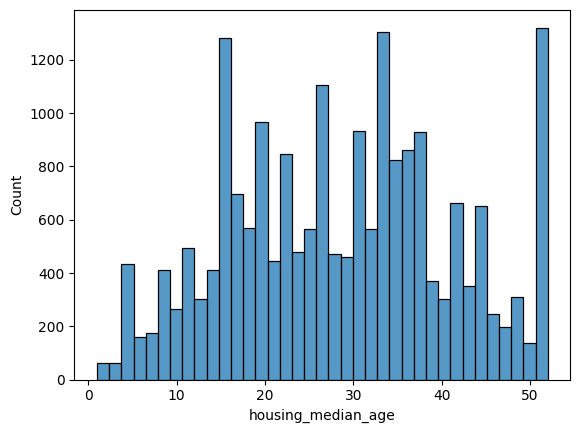

In [402]:
sns.histplot(df['housing_median_age'])

<Axes: xlabel='total_rooms', ylabel='Count'>

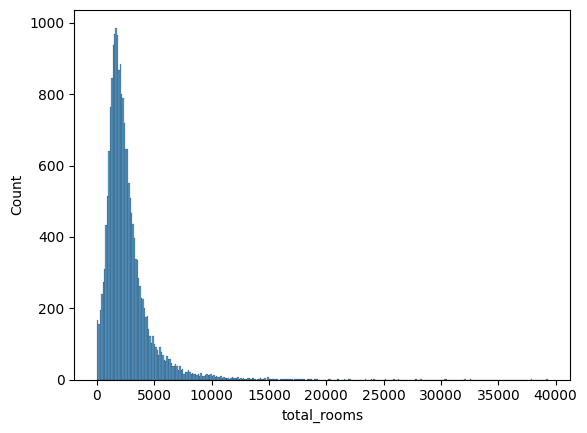

In [403]:
sns.histplot(df['total_rooms'])

In [404]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   population          20640 non-null  float64
 5   households          20640 non-null  float64
 6   median_income       20640 non-null  float64
 7   median_house_value  20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.4+ MB


In [405]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [406]:
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

In [407]:
#sns.histplot(df['total_bedrooms'])       # it is right squeed means tail in right

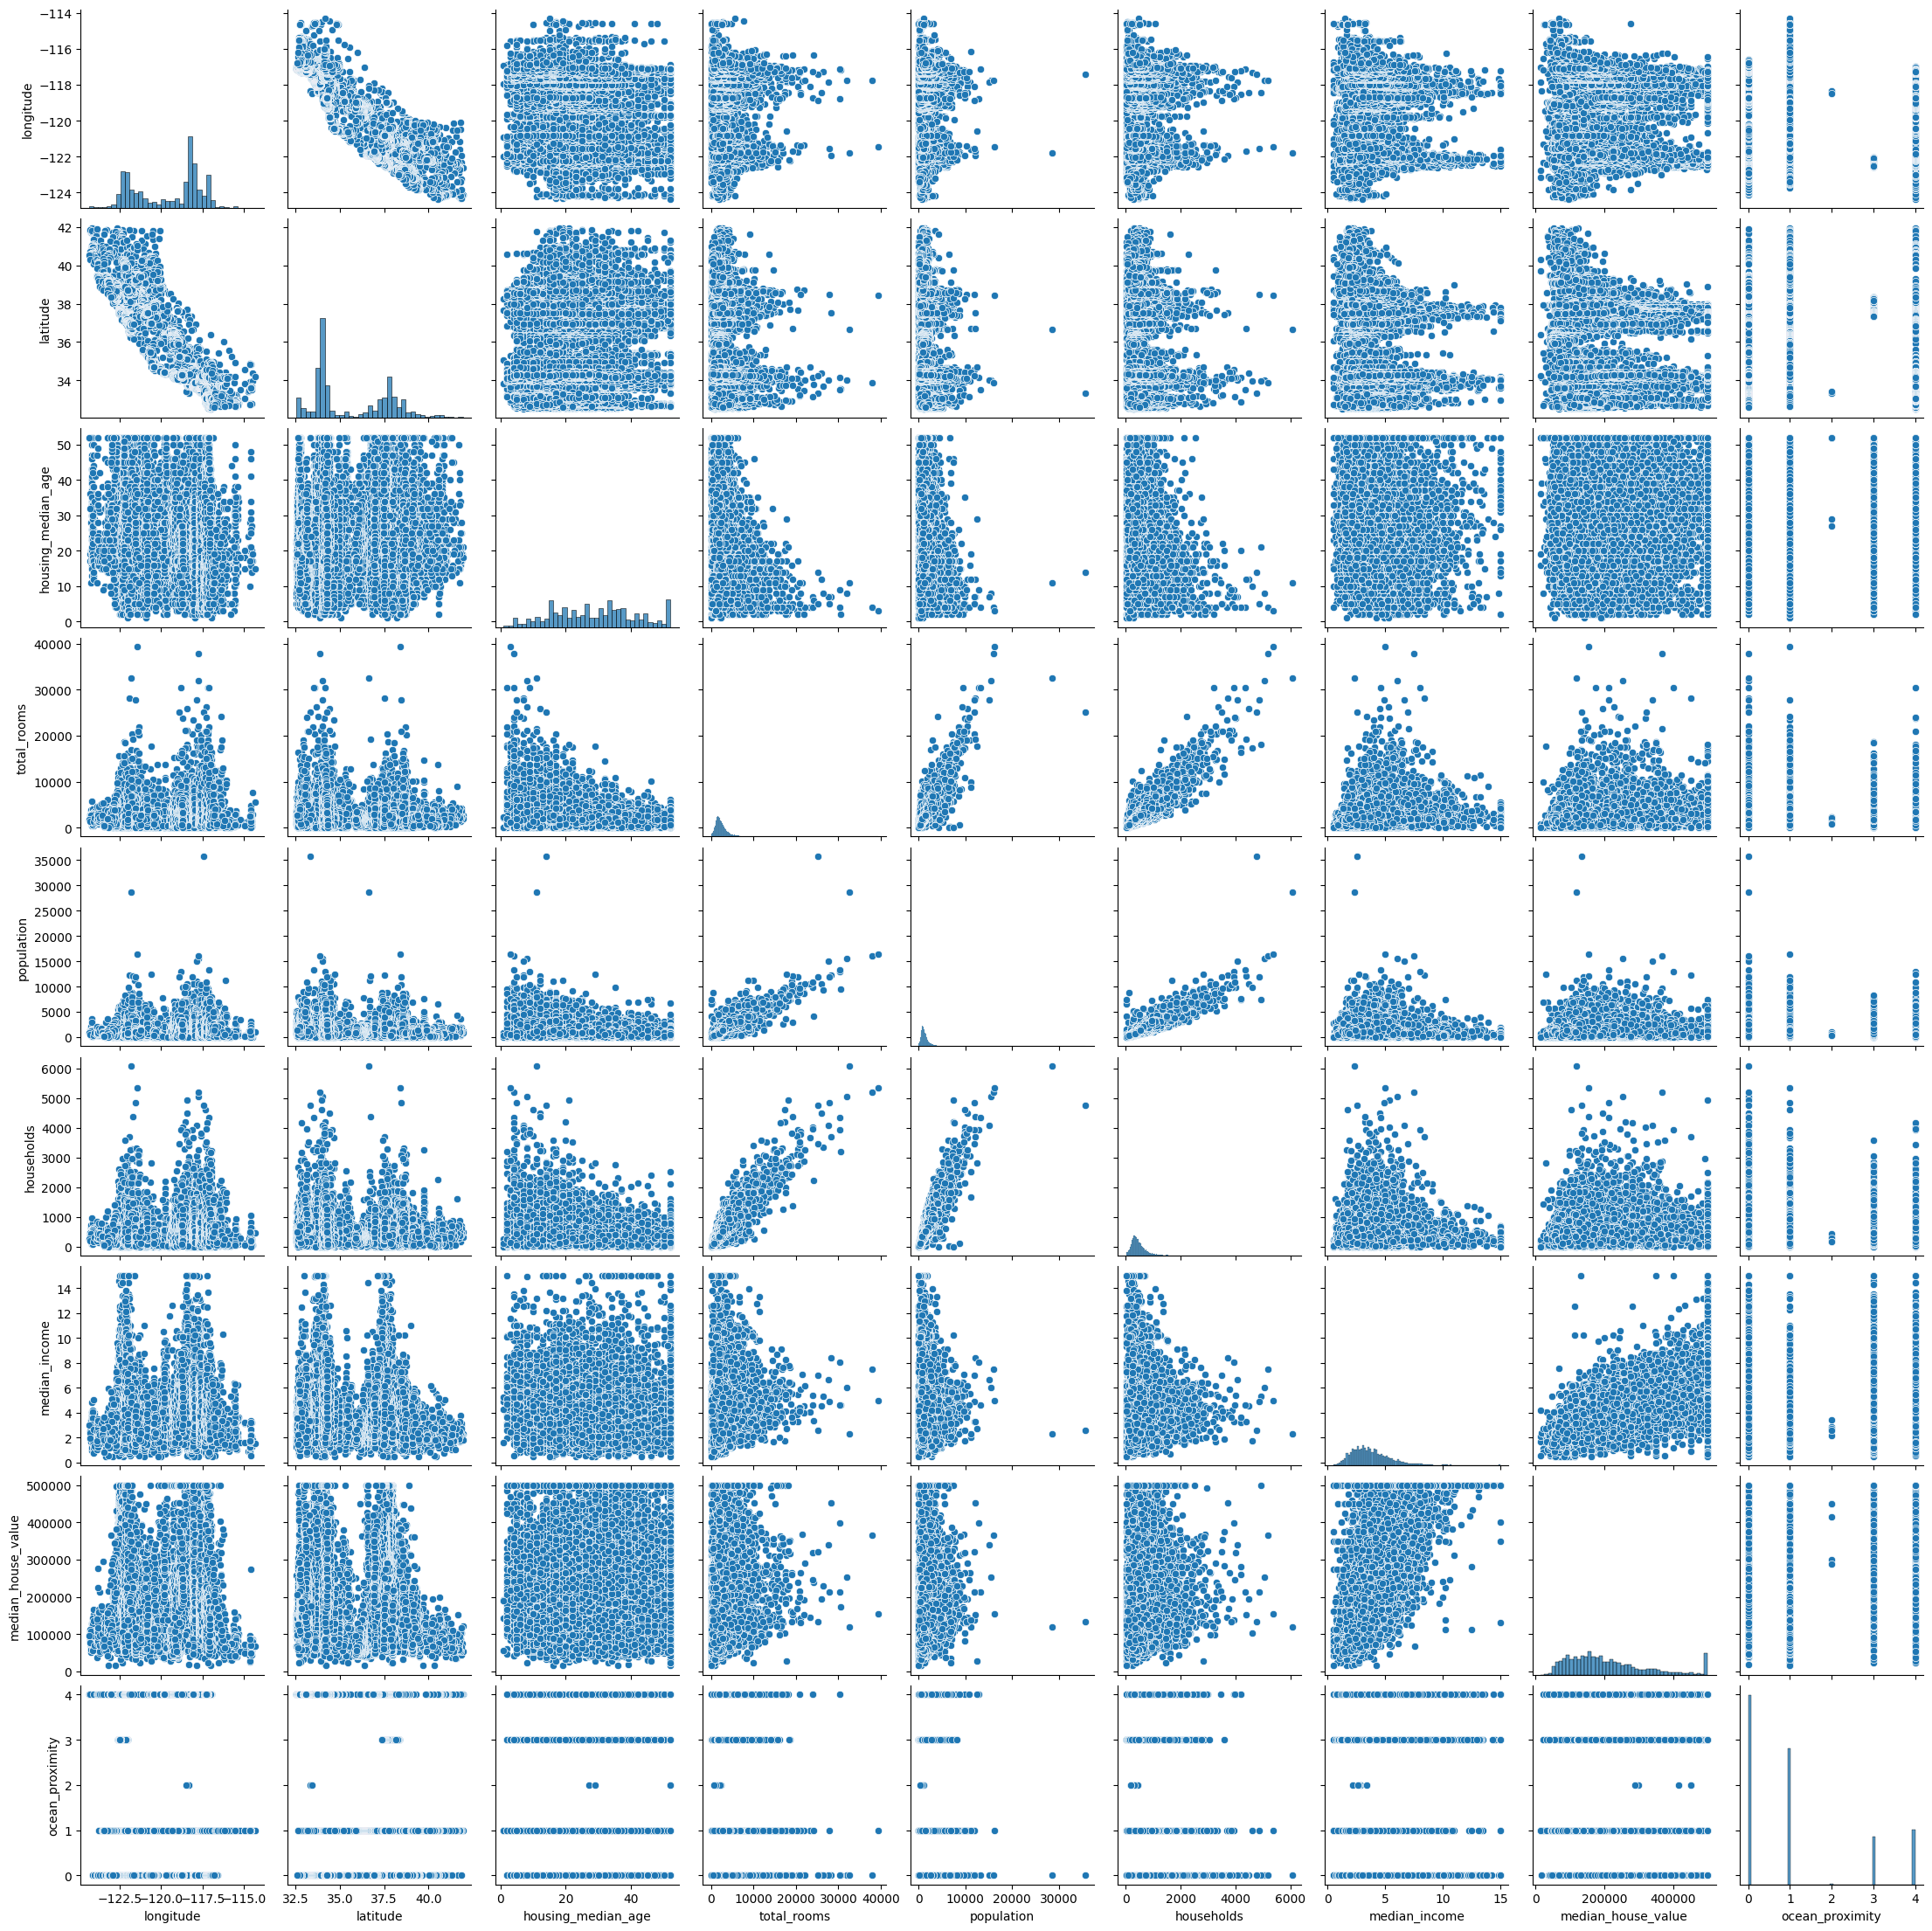

In [408]:
sns.pairplot(df)

In [409]:
label_df = df.groupby('ocean_proximity')['median_house_value'].mean().index

In [410]:
value_df = df.groupby('ocean_proximity')['median_house_value'].mean().values

([<matplotlib.patches.Wedge at 0x7f98b594e8d0>,
 [Text(0.9069461945525302, 0.6224536932067188, '0'),
  Text(0.06063620349674002, 1.0983274788629764, '1'),
  Text(-1.0294267935815449, 0.387660259320477, '2'),
  Text(-0.3548087797131467, -1.0412063819620334, '3'),
  Text(0.8921184642153465, -0.6435251710741793, '4')],
 [Text(0.49469792430138004, 0.3395201962945739, '19.15%'),
  Text(0.033074292816403644, 0.5990877157434417, '9.95%'),
  Text(-0.5615055237717517, 0.21145105053844196, '30.34%'),
  Text(-0.19353206166171638, -0.5679307537974727, '20.67%'),
  Text(0.4866100713901889, -0.35101372967682504, '19.89%')])

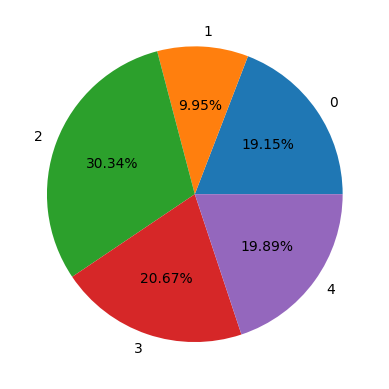

In [411]:
plt.pie(value_df,labels=label_df,autopct='%1.2f%%')

In [412]:
df.groupby('ocean_proximity')['housing_median_age'].mean()

,housing_median_age
ocean_proximity,
0,29.279225
1,24.271867
2,42.400000
3,37.730131
4,29.347254


In [413]:
label_df=df.groupby('ocean_proximity')['housing_median_age'].mean().index

In [414]:
value_df=df.groupby('ocean_proximity')['housing_median_age'].mean().values

([<matplotlib.patches.Wedge at 0x7f98b59932d0>,
 [Text(0.9295084863362975, 0.5882295247850156, '0'),
  Text(-0.027894224869812974, 1.0996462668598992, '1'),
  Text(-1.0628436346543915, 0.2834844056992247, '2'),
  Text(-0.3117285926775749, -1.0549053438613623, '3'),
  Text(0.9287365140751129, -0.5894476121112102, '4')],
 [Text(0.5070046289107076, 0.32085246806455386, '17.96%'),
  Text(-0.015215031747170711, 0.599807054650854, '14.89%'),
  Text(-0.579732891629668, 0.1546278576541225, '26.01%'),
  Text(-0.17003377782413173, -0.5754029148334702, '23.14%'),
  Text(0.5065835531318797, -0.32151687933338735, '18.00%')])

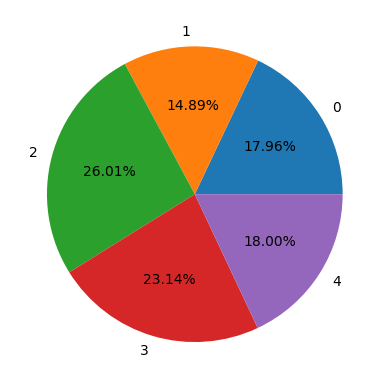

In [415]:
plt.pie(value_df,labels=label_df,autopct='%1.2f%%')

<Axes: xlabel='ocean_proximity', ylabel='median_house_value'>

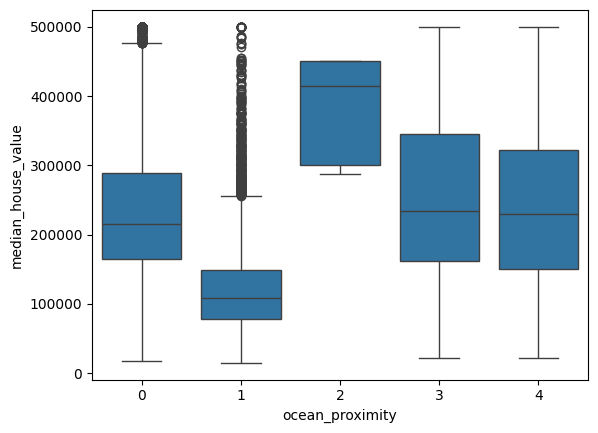

In [416]:
sns.boxplot(data=df,x='ocean_proximity',y='median_house_value')

In [417]:
df.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value,ocean_proximity
longitude,1.000000,-0.924664,-0.108197,0.044568,0.099773,0.055310,-0.015176,-0.045967,-0.289779
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.108785,-0.071035,-0.079809,-0.144160,0.200974
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.296244,-0.302916,-0.119034,0.105623,0.112468
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.857126,0.918484,0.198050,0.134153,-0.015693
population,0.099773,-0.108785,-0.296244,0.857126,1.000000,0.907222,0.004834,-0.024650,-0.070282
households,0.055310,-0.071035,-0.302916,0.918484,0.907222,1.000000,0.013033,0.065843,-0.018186
median_income,-0.015176,-0.079809,-0.119034,0.198050,0.004834,0.013033,1.000000,0.688075,-0.014957
median_house_value,-0.045967,-0.144160,0.105623,0.134153,-0.024650,0.065843,0.688075,1.000000,0.081750
ocean_proximity,-0.289779,0.200974,0.112468,-0.015693,-0.070282,-0.018186,-0.014957,0.081750,1.000000


<Axes: >

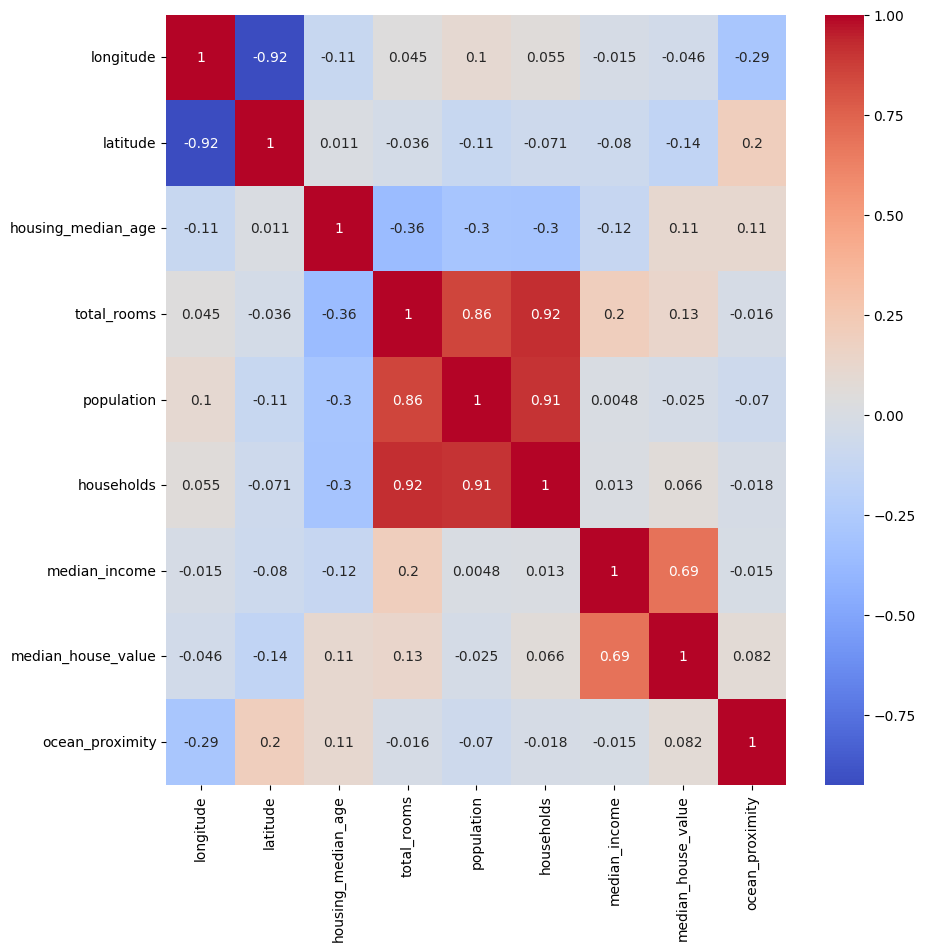

In [418]:
plt.figure(figsize=(10, 10),)  # To change the size of heatmap
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

In [419]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   population          20640 non-null  float64
 5   households          20640 non-null  float64
 6   median_income       20640 non-null  float64
 7   median_house_value  20640 non-null  float64
 8   ocean_proximity     20640 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.4 MB


In [420]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   population          20640 non-null  float64
 5   households          20640 non-null  float64
 6   median_income       20640 non-null  float64
 7   median_house_value  20640 non-null  float64
 8   ocean_proximity     20640 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.4 MB


In [421]:
X = df.drop('median_house_value',axis=1)
X = scaler.fit_transform(X)
y = df['median_house_value']

In [422]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [425]:
X=sc.fit_transform(X)

y=sc.fit_transform(y.values.reshape(-1,1))

In [426]:
X

array([[-1.32783522,  1.05254828,  0.98214266, ..., -0.97703285,
         2.34476576,  1.2910888 ],
       [-1.32284391,  1.04318455, -0.60701891, ...,  1.66996103,
         2.33223796,  1.2910888 ],
       [-1.33282653,  1.03850269,  1.85618152, ..., -0.84363692,
         1.7826994 ,  1.2910888 ],
       ...,
       [-0.8237132 ,  1.77823747, -0.92485123, ..., -0.17404163,
        -1.14259331, -0.11673923],
       [-0.87362627,  1.77823747, -0.84539315, ..., -0.39375258,
        -1.05458292, -0.11673923],
       [-0.83369581,  1.75014627, -1.00430931, ...,  0.07967221,
        -0.78012947, -0.11673923]])

In [427]:
y

array([[ 2.12963148],
       [ 1.31415614],
       [ 1.25869341],
       ...,
       [-0.99274649],
       [-1.05860847],
       [-1.01787803]])

In [428]:
df['median_house_value'].value_counts()

,count
median_house_value,
500001.0,965
137500.0,122
162500.0,117
112500.0,103
187500.0,93
...,...
34200.0,1
46200.0,1
352000.0,1


In [429]:
y = y.astype(int)

In [430]:
from imblearn.over_sampling import SMOTE     # we need to balance the data before Machine Learning

In [431]:
y_binned = pd.cut(y, bins=3, labels=[0, 1, 2])

ValueError: Input array must be 1 dimensional

In [432]:
sm = SMOTE(random_state=42)

In [433]:
X_res, y_res = sm.fit_resample(X, y_binned)

In [434]:
from sklearn.model_selection import train_test_split

In [435]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.33, random_state=42)

In [436]:
from sklearn.ensemble import RandomForestRegressor

In [437]:
rfr = RandomForestRegressor()

In [438]:
rfr.fit(X_train,y_train)

RandomForestRegressor()

In [439]:
y_pred = rfr.predict(X_test)

In [440]:
y_pred

array([0.36, 0.03, 0.  , ..., 1.98, 0.02, 0.93])

In [441]:
from sklearn.metrics import r2_score

In [442]:
r2_score(y_test,y_pred)

0.8286966518145735

In [443]:
from sklearn.neighbors import KNeighborsRegressor

In [444]:
knr = KNeighborsRegressor()

In [445]:
knr.fit(X_train,y_train)

KNeighborsRegressor()

In [446]:
y_pred = knr.predict(X_test)

In [447]:
y_pred

array([0.4, 0. , 0. , ..., 2. , 0. , 0.4])

In [448]:
r2_score(y_test,y_pred)

0.7577053336922289

In [449]:
from sklearn.tree import DecisionTreeRegressor

In [450]:
dtc = DecisionTreeRegressor()

In [451]:
dtc.fit(X_train,y_train)

DecisionTreeRegressor()

In [452]:
y_pred = dtc.predict(X_test)

In [453]:
y_pred

array([0., 0., 0., ..., 2., 0., 1.])

In [454]:
r2_score(y_test,y_pred)

0.6624024041990784

In [455]:
from sklearn.linear_model import LinearRegression

In [456]:
le = LinearRegression()

In [457]:
le.fit(X_train,y_train)

LinearRegression()

In [458]:
y_pred = le.predict(X_test)

In [459]:
y_pred

array([ 0.2571736 ,  0.54780113, -0.15573726, ...,  1.51452678,
        0.12933298,  1.00015438])

In [460]:
r2_score(y_test,y_pred)

0.5721105099483421

#Deap Learning

In [461]:
import keras
print(keras.__version__)

3.8.0


In [462]:
model = keras.Sequential()

In [463]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [464]:
df

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,565.0,259.0,3.8462,342200.0,3
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,845.0,330.0,1.5603,78100.0,1
20636,-121.21,39.49,18.0,697.0,356.0,114.0,2.5568,77100.0,1
20637,-121.22,39.43,17.0,2254.0,1007.0,433.0,1.7000,92300.0,1
20638,-121.32,39.43,18.0,1860.0,741.0,349.0,1.8672,84700.0,1


In [465]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [466]:
model.add(
    keras.Input(
        shape=(8,),
        batch_size=32
    )
)

In [467]:
model.add(                                 #hidden layer
    keras.layers.Dense(
    32,
    activation='relu'
))

In [468]:
model.add(                                 #hidden layer
    keras.layers.Dense(
    64,
    activation='relu'
))

In [469]:
model.add(                         ## Output layer
        keras.layers.Dense(
    128,
    activation='linear'   # use when we check 1 and 0
)
)

In [470]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (32, 32)               │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (32, 64)               │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (32, 128)              │         8,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,720 (41.88 KB)

 Trainable params: 10,720 (41.88 KB)

 Non-trainable params: 0 (0.00 B)

In [471]:
model.compile(
    optimizer="adam",
    loss='mse',
    metrics=['mae']
)


In [472]:
X_train.dtype

dtype('float64')

In [473]:
y_train.dtype

dtype('int64')

In [474]:
model.fit(
    x=X_train,
    y=y_train,
    batch_size=32,
    epochs=10,
    verbose="auto",
    validation_data=(X_test,y_test),
   # callbacks=[callback]
)

Epoch 1/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5964 - mae: 0.5882 - val_loss: 0.2269 - val_mae: 0.3673
Epoch 2/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2248 - mae: 0.3611 - val_loss: 0.2113 - val_mae: 0.3511
Epoch 3/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2096 - mae: 0.3455 - val_loss: 0.2069 - val_mae: 0.3446
Epoch 4/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2004 - mae: 0.3378 - val_loss: 0.1966 - val_mae: 0.3306
Epoch 5/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1958 - mae: 0.3305 - val_loss: 0.1943 - val_mae: 0.3300
Epoch 6/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1937 - mae: 0.3279 - val_loss: 0.1897 - val_mae: 0.3255
Epoch 7/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1879 - mae: 0.3231 - val_loss: 0.1869 - val_mae: 0.3244
Epoch 8/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1873 - mae: 0.3223 - val_loss: 0.1860 - val_mae: 0.3227
Epoch 9/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - lo

In [475]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1756 - mae: 0.3082


[0.18070843815803528, 0.31333494186401367]